In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import time

In [2]:
ctype = np.float64

### `init_grid` 
input: `shape`: (shape of a grid) ; `threshold`: density of the living cells 
output: `grid` 2darray of boolean 
initialize a random grid (2darray) of double float of dimension shape (the threshold help to define density)

In [3]:
def init_grid(shape, threshold=0.50):
    """
    initialize a random  grid of double float 
    of dimension shape (the threshold help to define density)
    """
    x = np.zeros(shape,dtype=ctype)
    r = np.random.random(shape)
    x[:,:] = (r> 1.0 - threshold)
    return x

In [4]:
def get_nbneigh(grid, coord):
    irange, jrange = grid.shape
    i, j = coord
    biinf = max(0, i - 1)
    bisup = min(irange - 1, i + 1)
    bjinf = max(0,j - 1)
    bjsup = min(jrange - 1,j + 1)
    nb_neigh = 0
    # loop over neighs to count living cells
    for ii in range(biinf, bisup + 1):
        for jj in range(bjinf, bjsup + 1):
            if grid[ii, jj]:
                nb_neigh = nb_neigh + 1
    # in my count I count current cell itself substract the value
    nb_neigh = nb_neigh-grid[i, j]
    return nb_neigh

### `life_step(grid)` : 
- input: `grid` a 2darray of cells (boolean); 
- output: `res_grid`  2darray ; the state of each cell of `grid` resulting from the application of the rules

In [5]:
def life_step(grid):
    irange, jrange = grid.shape
    res_grid = np.zeros(grid.shape,dtype=ctype)
    for j in range(jrange):
        for i in range(irange):
            # by default cell_state is dead
            cell_state = False
            # loop over neighs to count living cells
            nb_neigh = get_nbneigh(grid,(i,j))
            # if 2 neighbors cell state isn't modified
            if nb_neigh == 2:
                cell_state = grid[i, j]
            # if 3 neighbors cell state is alive
            elif nb_neigh == 3:
                cell_state = 1
            # in other case cell state is dead (default state)
            res_grid[i, j] = cell_state
    return res_grid

### `conway(grid,n)`
From an initial grid, run n iterations of evolution and display the intermediate statistics (number of alive cells)

In [6]:
def conway(grid, n):
    """
    From an initial grid, run n iterations of evolution and display 
    the intermediate statistics (number of alive cells)
    """
    for i in range(n):
        alive = np.sum(grid)
        print(f'alive cells: {alive:.0f}: {alive / grid.size * 100:2.2f}%')
        grid = life_step(grid)
    return grid

### Exemple on a little grid

In [7]:
grid = init_grid((10,10), 0.5)

In [8]:
grid

array([[1., 1., 1., 0., 0., 1., 1., 0., 1., 0.],
       [1., 1., 1., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 1., 0., 1., 1., 1., 0., 1.],
       [0., 1., 1., 0., 0., 0., 0., 1., 0., 1.],
       [1., 0., 1., 1., 1., 0., 0., 0., 0., 1.],
       [0., 1., 0., 1., 0., 1., 1., 0., 1., 0.],
       [1., 0., 0., 0., 1., 1., 0., 1., 0., 0.],
       [1., 1., 1., 0., 1., 1., 0., 0., 1., 1.],
       [0., 1., 1., 0., 0., 0., 0., 1., 1., 1.],
       [1., 1., 0., 0., 1., 1., 0., 1., 1., 1.]])

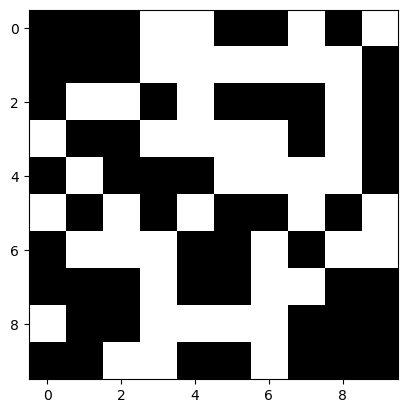

In [10]:
plt.imshow(grid,cmap=plt.cm.binary)

In [11]:
grid = life_step(grid)

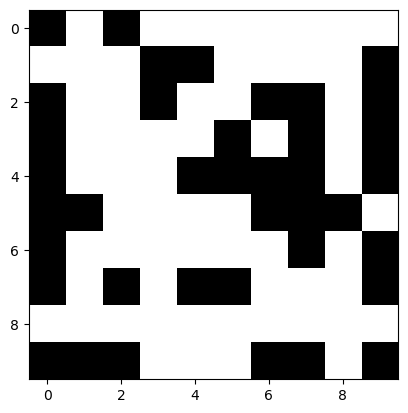

In [12]:
plt.imshow(grid,cmap=plt.cm.binary)

In [13]:
conway(grid,5)

alive cells: 39: 39.00%
alive cells: 33: 33.00%
alive cells: 37: 37.00%
alive cells: 30: 30.00%
alive cells: 34: 34.00%


array([[0., 0., 0., 0., 1., 0., 0., 0., 1., 0.],
       [0., 1., 0., 1., 1., 0., 0., 0., 0., 1.],
       [1., 0., 1., 0., 0., 1., 1., 0., 0., 1.],
       [1., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 0., 0., 0., 0., 0., 0., 1., 1.],
       [0., 1., 1., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 1., 0., 0., 0., 0., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

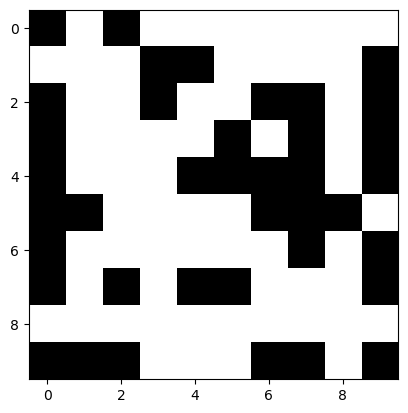

In [14]:
plt.imshow(grid,cmap=plt.cm.binary)

## Question 1.a 
Utilisez le notebook avec différentes tailles progressivement croissantes ((10,10) (100,100), (1000, 1000), (2000, 2000), …) et estimer les temps d’exécution de `conway` avec la commande magique `%time`

In [10]:
values_n = [10, 50, 100, 250, 500, 750, 1000, 1250, 1500, 1750, 2000]
times = []
n_cells = []


for n in values_n:

    grid = init_grid((n,n), 0.5)

    print("----- n = ",n," -----")  
    tic = time.time()
    %time conway(grid,5)
    toc = time.time()
    elapsed_time = toc - tic
    times.append(elapsed_time)
    
    n_cells.append(n*n)

----- n =  10  -----
alive cells: 49: 49.00%
alive cells: 37: 37.00%
alive cells: 40: 40.00%
alive cells: 34: 34.00%
alive cells: 29: 29.00%
CPU times: user 1.62 ms, sys: 0 ns, total: 1.62 ms
Wall time: 1.59 ms
----- n =  50  -----
alive cells: 1254: 50.16%
alive cells: 705: 28.20%
alive cells: 655: 26.20%
alive cells: 636: 25.44%
alive cells: 629: 25.16%
CPU times: user 25.8 ms, sys: 998 µs, total: 26.8 ms
Wall time: 26 ms
----- n =  100  -----
alive cells: 5036: 50.36%
alive cells: 2793: 27.93%
alive cells: 2502: 25.02%
alive cells: 2440: 24.40%
alive cells: 2290: 22.90%
CPU times: user 80.4 ms, sys: 0 ns, total: 80.4 ms
Wall time: 80.4 ms
----- n =  250  -----
alive cells: 31482: 50.37%
alive cells: 17044: 27.27%
alive cells: 15875: 25.40%
alive cells: 15607: 24.97%
alive cells: 14690: 23.50%
CPU times: user 503 ms, sys: 3 µs, total: 503 ms
Wall time: 502 ms
----- n =  500  -----
alive cells: 124968: 49.99%
alive cells: 68834: 27.53%
alive cells: 63370: 25.35%
alive cells: 62895: 25

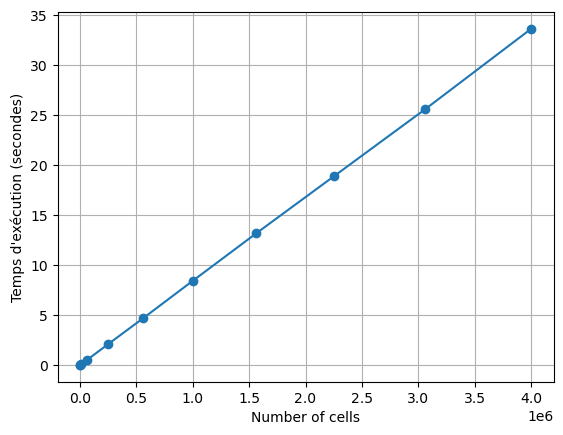

In [9]:
plt.plot(n_cells, times, marker='o')
plt.xlabel('Number of cells')
plt.ylabel("Temps d'exécution (secondes)")
plt.grid(True)
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    It is easy to observe the linear relationship between the execution time and the number of grid cells, which is expected, since during the execution of the function the same operations are performed in each of the cells.
  </p>
</div>

# Questions 2 cProfile

In [14]:
import cProfile

## Question 2.a 
Utilisez `cProfile` afin de réaliser un profilage du code (sur des grilles ayant un temps de restitution de quelques secondes ~1000x1000). Que remarquez-vous sur les fonctions les plus coûteuses ?

In [11]:
grid = init_grid((1000,1000), 0.5)

cProfile.run('conway(grid,5)', sort='ncalls')

alive cells: 499650: 49.96%
alive cells: 274642: 27.46%
alive cells: 254322: 25.43%
alive cells: 251307: 25.13%
alive cells: 238131: 23.81%
         25002844 function calls (25002832 primitive calls) in 11.695 seconds

   Ordered by: call count

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
 10000039    1.079    0.000    1.079    0.000 {built-in method builtins.max}
 10000014    1.042    0.000    1.042    0.000 {built-in method builtins.min}
  5000000    7.999    0.000   10.121    0.000 3970450040.py:1(get_nbneigh)
      517    0.000    0.000    0.000    0.000 {built-in method builtins.isinstance}
      210    0.000    0.000    0.000    0.000 enum.py:1544(_get_value)
      112    0.000    0.000    0.000    0.000 {built-in method builtins.len}
      100    0.000    0.000    0.000    0.000 enum.py:1129(__new__)
      100    0.000    0.000    0.000    0.000 enum.py:726(__call__)
       77    0.000    0.000    0.000    0.000 traitlets.py:643(get)
       77    0.00

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    We can see a slight increase in function execution time due to the use of the profiler. For this quick example, it doesn't represent a big difference, but this increase should be considered when analyzing functions with many hours of execution, for example.
  </p>
</div>

## Question 2.b 
Quel surcoût en temps d’exécution observez-vous par rapport à une exécution sans profilage ?

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    The overcost highlighted by the Profiler is the get_nbneigh function, as it is called once for each cell in every iteration, accounting for the longest total execution time. The profiler shows that the functions with the highest number of calls are max and min buildin functions, but there's no significant improvement that can be made in this regard, so it's not the function's biggest performance problem.
  </p>
</div>

## Question 2.c 
Générez la sortie du profilage dans un fichier `conway_01.prof`

In [ ]:
cProfile.run('conway(grid,5)', 'conway_01.prof')

alive cells: 499689: 49.97%
alive cells: 274894: 27.49%
alive cells: 253420: 25.34%
alive cells: 250218: 25.02%
alive cells: 237749: 23.77%


# Questions 3 optimisation 1 Inlining

## Question 3.a 
Créez une fonction `life_step_in` qui est une intégration du corps de `get_nbneigh` dans `life_step` et modifiez `conway` pour utiliser `life_step_in` à la place de `life_step`.

In [7]:
def life_step_in(grid):
    irange, jrange = grid.shape
    res_grid = np.zeros(grid.shape,dtype=ctype)
    for j in range(jrange):
        for i in range(irange):
            # by default cell_state is dead
            cell_state = False
            
            
            #### GET_NBNEIGH ####

            irange, jrange = grid.shape
            biinf = max(0, i - 1)
            bisup = min(irange - 1, i + 1)
            bjinf = max(0,j - 1)
            bjsup = min(jrange - 1,j + 1)
            nb_neigh = 0
            # loop over neighs to count living cells
            for ii in range(biinf, bisup + 1):
                for jj in range(bjinf, bjsup + 1):
                    if grid[ii, jj]:
                        nb_neigh = nb_neigh + 1
            # in my count I count current cell itself substract the value
            nb_neigh = nb_neigh-grid[i, j]


            # if 2 neighbors cell state isn't modified
            if nb_neigh == 2:
                cell_state = grid[i, j]
            # if 3 neighbors cell state is alive
            elif nb_neigh == 3:
                cell_state = 1
            # in other case cell state is dead (default state)
            res_grid[i, j] = cell_state
    return res_grid

In [8]:
def conway_in(grid, n):
    """
    From an initial grid, run n iterations of evolution and display 
    the intermediate statistics (number of alive cells)
    """
    for i in range(n):
        alive = np.sum(grid)
        print(f'alive cells: {alive:.0f}: {alive / grid.size * 100:2.2f}%')
        grid = life_step_in(grid)
    return grid

In [11]:
grid = init_grid((100,100), 0.5)
res = conway(grid,2)
res_in = conway(grid,2)
print(np.array_equal(res, res_in))

alive cells: 5076: 50.76%
alive cells: 2708: 27.08%
alive cells: 5076: 50.76%
alive cells: 2708: 27.08%
True


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    We can verify that both functions return the same result, confirming that it was correctly constructed.
  </p>
</div>

## Question 3.b 
Estimez les temps d’exécution de cette nouvelle version et réalisez un profilage avec `cProfile`. Que constatez vous sur les performances ?

In [11]:
values_n = [10, 50, 100, 250, 500, 750, 1000, 1250, 1500, 1750, 2000]
times2 = []

for n in values_n:

    grid = init_grid((n,n), 0.5)

    print("----- n = ",n," -----")  
    tic = time.time()
    %time conway_in(grid,5)
    toc = time.time()
    elapsed_time = toc - tic
    times2.append(elapsed_time)
    

----- n =  10  -----
alive cells: 45: 45.00%
alive cells: 41: 41.00%
alive cells: 35: 35.00%
alive cells: 36: 36.00%
alive cells: 39: 39.00%
CPU times: user 842 µs, sys: 0 ns, total: 842 µs
Wall time: 844 µs
----- n =  50  -----
alive cells: 1213: 48.52%
alive cells: 760: 30.40%
alive cells: 717: 28.68%
alive cells: 690: 27.60%
alive cells: 669: 26.76%
CPU times: user 27.3 ms, sys: 1.99 ms, total: 29.2 ms
Wall time: 28.8 ms
----- n =  100  -----
alive cells: 4998: 49.98%
alive cells: 2776: 27.76%
alive cells: 2556: 25.56%
alive cells: 2571: 25.71%
alive cells: 2371: 23.71%
CPU times: user 79.8 ms, sys: 0 ns, total: 79.8 ms
Wall time: 79.4 ms
----- n =  250  -----
alive cells: 31198: 49.92%
alive cells: 17431: 27.89%
alive cells: 15984: 25.57%
alive cells: 15721: 25.15%
alive cells: 14881: 23.81%
CPU times: user 475 ms, sys: 0 ns, total: 475 ms
Wall time: 475 ms
----- n =  500  -----
alive cells: 125299: 50.12%
alive cells: 68684: 27.47%
alive cells: 63263: 25.31%
alive cells: 62608: 25

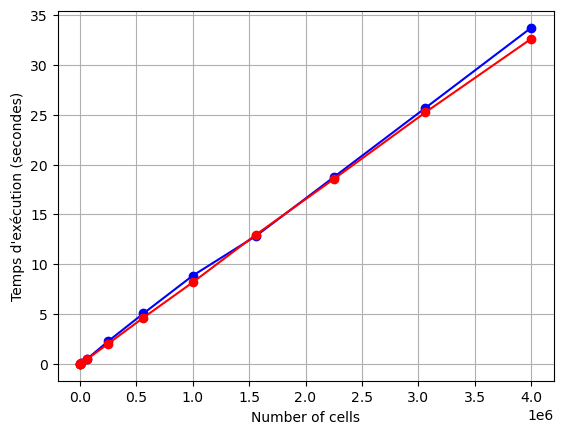

In [12]:
plt.plot(n_cells, times, marker='o', color='blue')
plt.plot(n_cells, times2, marker='o', color='red')
plt.xlabel('Number of cells')
plt.ylabel("Temps d'exécution (secondes)")
plt.grid(True)
plt.show()

In [15]:
grid = init_grid((1000,1000), 0.5)

cProfile.run('conway_in(grid,5)', sort='ncalls')

alive cells: 500400: 50.04%
alive cells: 273615: 27.36%
alive cells: 252664: 25.27%
alive cells: 249730: 24.97%
alive cells: 237702: 23.77%
         20002874 function calls (20002862 primitive calls) in 11.141 seconds

   Ordered by: call count

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
 10000043    1.101    0.000    1.101    0.000 {built-in method builtins.max}
 10000016    1.053    0.000    1.053    0.000 {built-in method builtins.min}
      517    0.000    0.000    0.000    0.000 {built-in method builtins.isinstance}
      210    0.000    0.000    0.000    0.000 enum.py:1544(_get_value)
      118    0.000    0.000    0.000    0.000 {built-in method builtins.len}
      100    0.000    0.000    0.000    0.000 enum.py:1129(__new__)
      100    0.000    0.000    0.000    0.000 enum.py:726(__call__)
       77    0.000    0.000    0.000    0.000 traitlets.py:643(get)
       77    0.000    0.000    0.000    0.000 traitlets.py:675(__get__)
       45    0.021  

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    It can be said that in terms of execution time, the conway and conway_in functions are in the same order of magnitude, with little variation. The profiling result also has a similar execution time. However, in this case, the function's overhead is not clearly displayed, since there is no call to the get_nbneigh function. Therefore, a more detailed profiling method is required.
  </p>
</div>

# Questions 4 Profilage life_step_in

## Question 4.a 
Avec line_profiler, profilez ligne à ligne la fonction life_step_in en ne jouant qu’une seule itération. 

In [18]:
from line_profiler import LineProfiler

In [23]:
grid = init_grid((1000,1000), 0.5)

In [ ]:
lp = LineProfiler()

lp.add_function(life_step_in)
lp.add_function(conway_in)

lp_wrapper = lp(conway_in)

lp_wrapper(grid, 1) 

lp.print_stats()

alive cells: 499535: 49.95%
Timer unit: 1e-07 s

Total time: 62.2553 s
File: C:\Users\ferna\AppData\Local\Temp\ipykernel_14716\1597321833.py
Function: conway_in at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def conway_in(grid, n):
     2                                               """
     3                                               From an initial grid, run n iterations of evolution and display 
     4                                               the intermediate statistics (number of alive cells)
     5                                               """
     6         2         57.0     28.5      0.0      for i in range(n):
     7         1      35174.0  35174.0      0.0          alive = np.sum(grid)
     8         1      27512.0  27512.0      0.0          print(f'alive cells: {alive:.0f}: {alive / grid.size * 100:2.2f}%')
     9         1  622490513.0 6.22e+08    100.0          grid = life_step_in(gri

## Question 4.b
Quel surcoût en temps d’exécution observez-vous par rapport à une exécution sans profilage ?

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    A large increase in the function's execution time can be seen when performing the analysis line by line, reaching an execution time almost 8 times greater than without using the profiler.
  </p>
</div>

## Question 4.c
Quels sont les hot spots mis en évidence par le profilage ligne à ligne ?

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    The line profiler further highlights that execution time is concentrated in the loop that runs through each cell, accumulating a large portion of the execution time. This suggests that developing the function so that it isn't necessary to perform these operations for each cell could bring significant performance gains.
  </p>
</div>